In [1]:
# ─── CELL 1: Install / upgrade dependencies ────────────────

!pip install -q ranx

!git clone https://github.com/TalentCLEF/talentclef26_evaluation_script.git /kaggle/working/talentclef26_evaluation_script

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 43.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.3 MB/s eta 0:00:00
Cloning into '/kaggle/working/talentclef26_evaluation_script'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 64 (delta 7), reused 60 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 29.46 KiB | 2.68 MiB/s, done.
Resolving deltas: 100% (7/

In [2]:
# ─── CELL 2: Imports ───────────────────────────────────────

import os, gc, math, random, warnings, subprocess
import glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset

from pathlib import Path
from tqdm.auto import tqdm

from transformers import (
    AutoModel,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

In [3]:
# ─── CELL 3: Reproducibility & device setup ────────────────

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

NUM_GPUS = torch.cuda.device_count()
print(f"GPUs available: {NUM_GPUS}")
for i in range(NUM_GPUS):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Primary device: {DEVICE}")

GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Primary device: cuda


In [4]:
# ─── CELL 4: Configuration ─────────────────────────────────

MODEL_NAME = "TechWolf/JobBERT-v3"
OUTPUT_DIR = "/kaggle/working/jobbertv3_output"
LOGGING_DIR = "/kaggle/working/jobbertv3_logs"

# Paths
TRAIN_CSV = (
    "/kaggle/input/datasets/danielantoniudumitru/"
    "clef-talentclef-subtaska/A/Training/"
    "normalization/job_applicant_dataset.csv"
)
DEV_BASE = "/kaggle/input/datasets/danielantoniudumitru/clef-talentclef-subtaska/A/Development/en"
CORPUS_DIR = os.path.join(DEV_BASE, "corpus")
QUERY_DIR = os.path.join(DEV_BASE, "queries")
QRELS_FILE = os.path.join(DEV_BASE, "qrels.tsv")

# Hyper-parameters
MAX_LEN = 512
TRAIN_BATCH = 8
EVAL_BATCH = 8
GRAD_ACCUM = 4
NUM_EPOCHS = 4
LR = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)

In [5]:
# ─── CELL 5: Load & inspect training data ──────────────────

print("Loading training CSV …")
df_train = pd.read_csv(TRAIN_CSV)
print(f"Shape : {df_train.shape}")
print(df_train.head(3))
print("\nColumn dtypes:\n", df_train.dtypes)
print("\nValue counts (label):\n", df_train.iloc[:, -1].value_counts())

Loading training CSV …
Shape : (10000, 9)
  Job Applicant Name  Age  Gender             Race   Ethnicity  \
0       Daisuke Mori   29    Male  Mongoloid/Asian  Vietnamese   
1     Taichi Shimizu   31    Male  Mongoloid/Asian    Filipino   
2       Sarah Martin   46  Female  White/Caucasian       Dutch   

                                              Resume          Job Roles  \
0  Daisuke Mori\n243 Hill Street\nAmsterdam, Nort...      Fitness Coach   
1  Taichi Shimizu\n108 Market Street\nCape Town, ...          Physician   
2  Sarah Martin\n10 Lincoln Avenue\nMumbai, Mahar...  Financial Analyst   

                                     Job Description  Best Match  
0  Fitness Coach\n\nA Fitness Coach is responsibl...           0  
1  Physician\n\nDiagnose and treat illnesses, pre...           0  
2  Financial Analyst\n\nAs a Financial Analyst, y...           0  

Column dtypes:
 Job Applicant Name    object
Age                    int64
Gender                object
Race                

In [6]:
# ─── CELL 6: Define columns (hardcoded for this dataset) ───

text_a_col = "Job Description"
text_b_col = "Resume"
label_col = "Best Match"

print(f"Text A: {text_a_col}")
print(f"Text B: {text_b_col}")
print(f"Label: {label_col}")

df_train[label_col] = df_train[label_col].astype(int)
assert set(df_train[label_col].unique()).issubset({0, 1}), \
    "Label column must contain only 0 and 1!"

Text A: Job Description
Text B: Resume
Label: Best Match


In [7]:
# ─── CELL 7: Tokenizer ─────────────────────────────────────

print(f"\nLoading tokenizer: {MODEL_NAME} …")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


Loading tokenizer: TechWolf/JobBERT-v3 …


config.json:   0%|          | 0.00/697 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

In [8]:
# ─── CELL 8: Helper — read dev corpus / queries ───────────

def read_text_file(folder, file_id):
    path = os.path.join(folder, str(file_id))
    if not os.path.exists(path):
        return ""
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return f.read().strip()

In [9]:
# ─── CELL 9: Load qrels ───────────────────────────────────

print("\nLoading qrels …")
qrels = pd.read_csv(
    QRELS_FILE, sep="\t", header=None,
    names=["q_id", "iter", "c_id", "relevance"]
)
print(f"qrels shape: {qrels.shape}")
print(qrels.head())


Loading qrels …
qrels shape: (472, 4)
    q_id  iter   c_id  relevance
0  36044     0  13884          1
1  39060     0   9516          1
2  39060     0  12097          1
3  32447     0  13882          1
4  39060     0   6533          1


In [10]:
# ─── CELL 10: Load all corpus & query files, build all pairs ───

print("\nLoading all query files …")
query_dict = {}
for fpath in sorted(glob.glob(os.path.join(QUERY_DIR, "*"))):
    fid = os.path.basename(fpath)
    query_dict[fid] = read_text_file(QUERY_DIR, fid)
print(f"  Queries found: {len(query_dict)}")

print("Loading all corpus files …")
corpus_dict = {}
for fpath in sorted(glob.glob(os.path.join(CORPUS_DIR, "*"))):
    fid = os.path.basename(fpath)
    corpus_dict[fid] = read_text_file(CORPUS_DIR, fid)
print(f"  Corpus elements found: {len(corpus_dict)}")

positive_set = set(zip(
    qrels["q_id"].astype(str),
    qrels["c_id"].astype(str)
))

print("\nBuilding all (query × corpus) pairs …")
dev_records = []
for q_id, q_text in tqdm(query_dict.items(), desc="Queries"):
    for c_id, c_text in corpus_dict.items():
        dev_records.append({
            "q_id": q_id,
            "c_id": c_id,
            "query_text": q_text,
            "corpus_text": c_text,
            "relevance": 1 if (q_id, c_id) in positive_set else 0,
        })

df_dev = pd.DataFrame(dev_records)

print(f"Total pairs: {len(df_dev)}")
print(f"Positives: {(df_dev['relevance']==1).sum()}")
print(f"Negatives: {(df_dev['relevance']==0).sum()}")


Loading all query files …
  Queries found: 10
Loading all corpus files …
  Corpus elements found: 472

Building all (query × corpus) pairs …


Queries:   0%|          | 0/10 [00:00<?, ?it/s]

Total pairs: 4720
Positives: 472
Negatives: 4248


In [11]:
# ─── CELL 11: Dataset & model components ───────────────────

class SingleTextDataset(Dataset):
    def __init__(self, texts, ids, tokenizer, max_len):
        self.texts = texts
        self.ids = ids
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            " ".join(str(self.texts[idx]).split()[:384]),
            max_length=self.max_len,
            truncation=True,
            padding=False,
            return_token_type_ids=False,
        )
        return enc


def mean_pooling(model_output, attention_mask):
    token_emb  = model_output.last_hidden_state
    mask_exp   = attention_mask.unsqueeze(-1).expand(token_emb.size()).float()
    return torch.sum(token_emb * mask_exp, 1) / torch.clamp(mask_exp.sum(1), min=1e-9)


class TripletDataset(Dataset):
    def __init__(self, df, tokenizer, max_len,
                 q_col, pos_col, neg_col):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.q_col = q_col
        self.pos_col = pos_col
        self.neg_col = neg_col
        self.data = df.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def _enc(self, text):
        return self.tokenizer(
            " ".join(str(text).split()[:384]),
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
            return_token_type_ids=False
        )

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        return {
            "q_input_ids": self._enc(row[self.q_col])["input_ids"].squeeze(0),
            "q_attention_mask": self._enc(row[self.q_col])["attention_mask"].squeeze(0),
            "p_input_ids": self._enc(row[self.pos_col])["input_ids"].squeeze(0),
            "p_attention_mask": self._enc(row[self.pos_col])["attention_mask"].squeeze(0),
            "n_input_ids": self._enc(row[self.neg_col])["input_ids"].squeeze(0),
            "n_attention_mask": self._enc(row[self.neg_col])["attention_mask"].squeeze(0)
        }

In [12]:
# ─── CELL 12: Build triplet train/validation sets ──────────

NUM_CROSS_ROLE_NEGS = 1

positives = df_train[df_train[label_col] == 1].reset_index(drop=True)
negatives = df_train[df_train[label_col] == 0].reset_index(drop=True)

random.seed(SEED)

neg_by_role = {}
for _, row in negatives.iterrows():
    role = str(row.get("Job Roles", "unknown"))
    neg_by_role.setdefault(role, []).append(row[text_b_col])

all_neg_texts = negatives[text_b_col].tolist()
all_roles = list(neg_by_role.keys())

triplets = []
for _, row in positives.iterrows():
    query_role = str(row.get("Job Roles", "unknown"))

    other_roles = [r for r in all_roles if r != query_role]
    if other_roles:
        neg_role = random.choice(other_roles)
        neg_pool = neg_by_role[neg_role]
    else:
        neg_pool = all_neg_texts

    neg_text = random.choice(neg_pool)
    triplets.append({
        "query"   : row[text_a_col],
        "positive": row[text_b_col],
        "negative": neg_text
    })

df_triplets = pd.DataFrame(triplets)

df_trip_train, df_trip_val = train_test_split(
    df_triplets, test_size=0.1, random_state=SEED
)
print(f"Triplet train : {len(df_trip_train)}")
print(f"Triplet val: {len(df_trip_val)}")

train_dataset = TripletDataset(df_trip_train, tokenizer, MAX_LEN,
                                "query", "positive", "negative")
val_dataset = TripletDataset(df_trip_val, tokenizer, MAX_LEN,
                                "query", "positive", "negative")
data_collator = None

Triplet train : 4365
Triplet val: 485


In [13]:
# ─── CELL 13: Bi-encoder model ─────────────────────────────

class BiEncoder(nn.Module):
    def __init__(self, model_name, proj_dim=256):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        self.embed_dim = self.encoder.config.hidden_size
        self.proj = nn.Sequential(
            nn.Linear(self.embed_dim, proj_dim),
            nn.LayerNorm(proj_dim),
        )
        self.tau = 0.05

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids,
                           attention_mask=attention_mask)
        emb = mean_pooling(out, attention_mask)
        emb = self.proj(emb)                    
        return F.normalize(emb, p=2, dim=-1)

    def get_temp(self):
        return self.tau

    def forward(self, q_input_ids, q_attention_mask,
                p_input_ids, p_attention_mask,
                n_input_ids, n_attention_mask):
        q_emb = self.encode(q_input_ids, q_attention_mask)
        p_emb = self.encode(p_input_ids, p_attention_mask)
        n_emb = self.encode(n_input_ids, n_attention_mask)
        return q_emb, p_emb, n_emb

model = BiEncoder(MODEL_NAME, proj_dim=256).to(DEVICE)
if NUM_GPUS > 1:
    model = nn.DataParallel(model)

_m = model.module if hasattr(model, "module") else model
print(f"Bi-encoder parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"Temperature           : {_m.get_temp()}")

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Bi-encoder parameters : 278,241,024
Temperature           : 0.05


In [14]:
# ─── CELL 14: Metrics ──────────────────────────────────────

def compute_metrics(eval_pred):
    # Ranking quality is measured at inference time, not during training
    return {}

In [15]:
# ─── CELL 15: TrainingArguments ────────────────────────────

steps_per_epoch = math.ceil(len(train_dataset) / (TRAIN_BATCH * max(NUM_GPUS, 1) * GRAD_ACCUM))
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

os.environ["TENSORBOARD_LOGGING_DIR"] = LOGGING_DIR

training_args = TrainingArguments(
    output_dir = OUTPUT_DIR,
    logging_dir = LOGGING_DIR,

    # Epochs & batch
    num_train_epochs = NUM_EPOCHS,
    per_device_train_batch_size = TRAIN_BATCH,
    per_device_eval_batch_size = EVAL_BATCH,
    gradient_accumulation_steps = GRAD_ACCUM,

    # Optimiser
    learning_rate = LR,
    weight_decay = WEIGHT_DECAY,
    warmup_steps = warmup_steps,
    lr_scheduler_type = "cosine",
    max_grad_norm = 1.0,

    # Evaluation & saving
    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "eval_loss",
    greater_is_better = False,
    remove_unused_columns = False,

    # Logging
    report_to = "none",

    # Multi-GPU / precision
    fp16 = True,
    dataloader_num_workers = 4,
    seed = SEED,

    # Progress bar
    disable_tqdm = False
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [16]:
# ─── CELL 16: Triplet Trainer ───────────────────────────────

class TripletTrainer(Trainer):
    def _remove_unused_columns(self, dataset, description=None):
        return dataset

    def create_optimizer(self):
        _model = self.model.module if hasattr(self.model, "module") else self.model
        encoder = _model.encoder
        proj = _model.proj
        no_decay = {"bias", "LayerNorm.weight", "LayerNorm.bias"}

        base_lr = self.args.learning_rate
        decay_factor = 0.9
        num_layers = encoder.config.num_hidden_layers

        param_groups = []

        for name, param in proj.named_parameters():
            param_groups.append({
                "params": [param],
                "lr": 1e-4,
                "weight_decay": 0.0 if any(nd in name for nd in no_decay) else 0.01
            })

        for layer_idx in range(num_layers - 1, -1, -1):
            layer_lr = base_lr * (decay_factor ** (num_layers - 1 - layer_idx))
            for name, param in encoder.encoder.layer[layer_idx].named_parameters():
                param_groups.append({
                    "params": [param],
                    "lr": layer_lr,
                    "weight_decay": 0.0 if any(nd in name for nd in no_decay) else 0.01
                })

        embed_lr = base_lr * (decay_factor ** num_layers)
        for name, param in encoder.embeddings.named_parameters():
            param_groups.append({
                "params": [param],
                "lr": embed_lr,
                "weight_decay": 0.0 if any(nd in name for nd in no_decay) else 0.01
            })

        self.optimizer = AdamW(param_groups)
        return self.optimizer

    def prediction_step(self, model, inputs, prediction_loss_only,
                        ignore_keys=None):
        model.eval()
        with torch.no_grad():
            result = self.compute_loss(model, inputs, return_outputs=True)
            loss   = result[0]
        return (loss.detach(), None, None)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        _model = model.module if hasattr(model, "module") else model

        q_emb, p_emb, n_emb = model(
            q_input_ids = inputs["q_input_ids"],
            q_attention_mask = inputs["q_attention_mask"],
            p_input_ids = inputs["p_input_ids"],
            p_attention_mask = inputs["p_attention_mask"],
            n_input_ids = inputs["n_input_ids"],
            n_attention_mask = inputs["n_attention_mask"]
        )

        tau = _model.get_temp()
        all_sims = torch.mm(q_emb, p_emb.T) / tau
        labels = torch.arange(q_emb.size(0)).to(q_emb.device)
        loss = F.cross_entropy(all_sims, labels)

        return (loss, (q_emb, p_emb, n_emb)) if return_outputs else loss


trainer = TripletTrainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]
)

In [17]:
# ─── CELL 17: Training ─────────────────────────────────────

print("\n" + "="*60)
print("  Starting JobBERTv3 fine-tuning …")
print("="*60)

train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("\nTraining summary:")
print(train_result.metrics)


  Starting JobBERTv3 fine-tuning …


Epoch,Training Loss,Validation Loss
1,No log,0.085099
2,No log,0.033143
3,No log,0.025466
4,No log,0.023536



Training summary:
{'train_runtime': 841.582, 'train_samples_per_second': 20.747, 'train_steps_per_second': 0.328, 'total_flos': 0.0, 'train_loss': 0.07494909175928088, 'epoch': 4.0}


In [18]:
# ─── CELL 18: Encode all corpus and query texts separately ──

def encode_texts(text_dict, tokenizer, model, max_len, batch_size=32, desc="Encoding"):
    ids = list(text_dict.keys())
    texts = list(text_dict.values())
    all_embs = []

    _model = model.module if hasattr(model, "module") else model

    _model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=desc):
            batch_texts = [" ".join(str(t).split()[:384]) for t in texts[i:i+batch_size]]
            enc = tokenizer(
                batch_texts,
                max_length=max_len,
                truncation=True,
                padding=True,
                return_tensors="pt",
                return_token_type_ids=False
            ).to(DEVICE)
            out  = _model.encoder(**enc)
            embs = mean_pooling(out, enc["attention_mask"])
            embs = F.normalize(embs, p=2, dim=-1)
            all_embs.append(embs.cpu().numpy())

    all_embs = np.vstack(all_embs)
    return {id_: emb for id_, emb in zip(ids, all_embs)}

print("\nEncoding queries …")
query_embeddings  = encode_texts(query_dict,  tokenizer, model, MAX_LEN, desc="Queries")
print("Encoding corpus …")
corpus_embeddings = encode_texts(corpus_dict, tokenizer, model, MAX_LEN, desc="Corpus")


Encoding queries …


Queries:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding corpus …


Corpus:   0%|          | 0/15 [00:00<?, ?it/s]

In [19]:
# ─── CELL 19: Score all (query × corpus) pairs ─────────────

print("\nScoring all query × corpus pairs …")

q_ids_list = list(query_embeddings.keys())
c_ids_list = list(corpus_embeddings.keys())

Q = np.stack([query_embeddings[q]  for q in q_ids_list])
C = np.stack([corpus_embeddings[c] for c in c_ids_list])

sim_matrix = Q @ C.T

records = []
for i, q_id in enumerate(q_ids_list):
    for j, c_id in enumerate(c_ids_list):
        records.append({
            "q_id": q_id,
            "c_id": c_id,
            "pred_prob": float(sim_matrix[i, j]),
            "relevance": 1 if (str(q_id), str(c_id)) in positive_set else 0
        })

df_dev = pd.DataFrame(records)
print(f"Scored pairs: {len(df_dev)}")
print(f"Positives: {(df_dev['relevance']==1).sum()}")

labels = df_dev["relevance"].values
probs = df_dev["pred_prob"].values
preds_bin = (probs >= 0.5).astype(int)
df_dev["pred_label"] = preds_bin


Scoring all query × corpus pairs …
Scored pairs: 4720
Positives: 472


In [20]:
# ─── CELL 19b: Generate TREC run file ──────────────────────

RUN_TAG = "jobbertv3_run"
RUN_PATH = "/kaggle/working/run_en-en_jobbertv3.trec"

print("Generating TREC run file …")

run_rows = []
for q_id, grp in df_dev.groupby("q_id"):
    grp_sorted = grp.sort_values("pred_prob", ascending=False).reset_index(drop=True)
    for rank_idx, row in grp_sorted.iterrows():
        run_rows.append({
            "q_id": str(row["q_id"]),
            "Q0": "Q0",
            "doc_id": str(row["c_id"]),
            "rank": int(grp_sorted.index.get_loc(rank_idx)) + 1,
            "score": float(row["pred_prob"]),
            "tag": RUN_TAG
        })

df_run = pd.DataFrame(run_rows)

df_run = []
for q_id, grp in df_dev.groupby("q_id"):
    grp_sorted = grp.sort_values("pred_prob", ascending=False).reset_index(drop=True)
    for rank, (_, row) in enumerate(grp_sorted.iterrows(), start=1):
        df_run.append({
            "q_id": str(row["q_id"]),
            "Q0": "Q0",
            "doc_id": str(row["c_id"]),
            "rank": rank,
            "score": float(row["pred_prob"]),
            "tag": RUN_TAG
        })
df_run = pd.DataFrame(df_run)

with open(RUN_PATH, "w") as f:
    for _, row in df_run.iterrows():
        f.write(f"{row['q_id']} {row['Q0']} {row['doc_id']} "
                f"{row['rank']} {row['score']:.10f} {row['tag']}\n")

print(f"Run file saved: {RUN_PATH}")
print(f"  Total lines  : {len(df_run)}")
print(f"  Unique queries: {df_run['q_id'].nunique()}")
print(df_run.head(5).to_string(index=False))

Generating TREC run file …
Run file saved: /kaggle/working/run_en-en_jobbertv3.trec
  Total lines  : 4720
  Unique queries: 10
 q_id Q0 doc_id  rank    score           tag
29243 Q0  10744     1 0.676769 jobbertv3_run
29243 Q0   7493     2 0.638940 jobbertv3_run
29243 Q0  20128     3 0.637259 jobbertv3_run
29243 Q0  11695     4 0.635271 jobbertv3_run
29243 Q0   5397     5 0.632939 jobbertv3_run


In [21]:
# ─── CELL 19c: Official TalentCLEF 2026 evaluation ─────────

import ranx

qrels_file = QRELS_FILE
run_file = RUN_PATH

print("Running official TalentCLEF 2026 evaluation …")
print(f"  qrels : {qrels_file}")
print(f"  run   : {run_file}")

command = [
    "python",
    "/kaggle/working/talentclef26_evaluation_script/talentclef_evaluate.py",
    "--task", "A",
    "--lang-mode", "en",
    "--qrels", qrels_file,
    "--run", run_file
]

result = subprocess.run(command, capture_output=True, text=True)

print("\n" + "="*60)
print("  Official Evaluation Results")
print("="*60)
print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

Running official TalentCLEF 2026 evaluation …
  qrels : /kaggle/input/datasets/danielantoniudumitru/clef-talentclef-subtaska/A/Development/en/qrels.tsv
  run   : /kaggle/working/run_en-en_jobbertv3.trec

  Official Evaluation Results
TalentCLEF 2026 - Task A Evaluation
Received parameters:
  Task: A
  Qrels: /kaggle/input/datasets/danielantoniudumitru/clef-talentclef-subtaska/A/Development/en/qrels.tsv
  Run: /kaggle/working/run_en-en_jobbertv3.trec
  Language Mode: en

Loading qrels...
Loading run...

Running Task A evaluation...

EVALUATION RESULTS
map: 0.8200
mrr: 0.9200
ndcg: 0.9409
precision@5: 0.9200
precision@10: 0.9000
precision@100: 0.4120

STDERR:
/usr/local/lib/python3.12/dist-packages/ranx/metrics/average_precision.py:49: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  scores[i] = _average_precision(qrels[i], run[i], k, rel_lvl)



In [22]:
# ─── CELL 20: Ranking Metrics ──────────────────────────────

def mean_average_precision(df, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    aps = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).reset_index(drop=True)
        rel = grp_sorted[rel_col].values
        if rel.sum() == 0:
            continue
        hits, ap = 0, 0.0
        for rank, r in enumerate(rel, start=1):
            if r == 1:
                hits += 1
                ap += hits / rank
        aps.append(ap / rel.sum())
    return np.mean(aps) if aps else 0.0


def mean_reciprocal_rank(df, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    rrs = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).reset_index(drop=True)
        rel = grp_sorted[rel_col].values
        rr = 0.0
        for rank, r in enumerate(rel, start=1):
            if r == 1:
                rr = 1.0 / rank
                break
        rrs.append(rr)
    return np.mean(rrs) if rrs else 0.0


def precision_at_k(df, k, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    pk_list = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).head(k)
        pk_list.append(grp_sorted[rel_col].mean())
    return np.mean(pk_list) if pk_list else 0.0

In [23]:
# ─── CELL 21: Print all metrics ────────────────────────────

MAP = mean_average_precision(df_dev)
MRR = mean_reciprocal_rank(df_dev)
P_at1 = precision_at_k(df_dev, k=1)
P_at5 = precision_at_k(df_dev, k=5)
P_at10 = precision_at_k(df_dev, k=10)

print("\n" + "="*60)
print("  JobBERTv3 — Dev Set Evaluation Results")
print("─"*60)
print(f"  MAP(Mean Avg Precision): {MAP:.4f}")
print(f"  MRR(Mean Recip Rank): {MRR:.4f}")
print(f"  P@1: {P_at1:.4f}")
print(f"  P@5: {P_at5:.4f}")
print(f"  P@10: {P_at10:.4f}")
print("="*60)


  JobBERTv3 — Dev Set Evaluation Results
────────────────────────────────────────────────────────────
  MAP(Mean Avg Precision): 0.8200
  MRR(Mean Recip Rank): 0.9200
  P@1: 0.9000
  P@5: 0.9200
  P@10: 0.9000


In [24]:
# ─── CELL 22: Save predictions ─────────────────────────────

df_dev.to_csv("/kaggle/working/jobbert_dev_predictions.csv", index=False)
print("\nPredictions saved to /kaggle/working/jobbertv3_dev_predictions.csv")


Predictions saved to /kaggle/working/jobbertv3_dev_predictions.csv


In [25]:
# ─── CELL 23: Extract training history ─────────────────────

log_history = trainer.state.log_history

train_logs = [e for e in log_history if "loss" in e and "eval_loss" not in e]
eval_logs  = [e for e in log_history if "eval_loss" in e]

eval_epochs = [e["epoch"] for e in eval_logs]
eval_loss = [e["eval_loss"] for e in eval_logs]

train_epochs_raw = [e["epoch"] for e in train_logs]
train_loss_raw   = [e["loss"]  for e in train_logs]

train_loss_per_epoch = []
for ep in eval_epochs:
    lo = ep - 1.0
    vals = [train_loss_raw[i] for i, e in enumerate(train_epochs_raw) if lo < e <= ep]
    train_loss_per_epoch.append(np.mean(vals) if vals else float("nan"))

print(f"Epochs recorded: {eval_epochs}")
print(f"Train loss per epoch: {[round(v,4) for v in train_loss_per_epoch]}")
print(f"Eval  loss per epoch: {[round(v,4) for v in eval_loss]}")

Epochs recorded: [1.0, 2.0, 3.0, 4.0]
Train loss per epoch: [nan, nan, nan, nan]
Eval  loss per epoch: [0.0851, 0.0331, 0.0255, 0.0235]


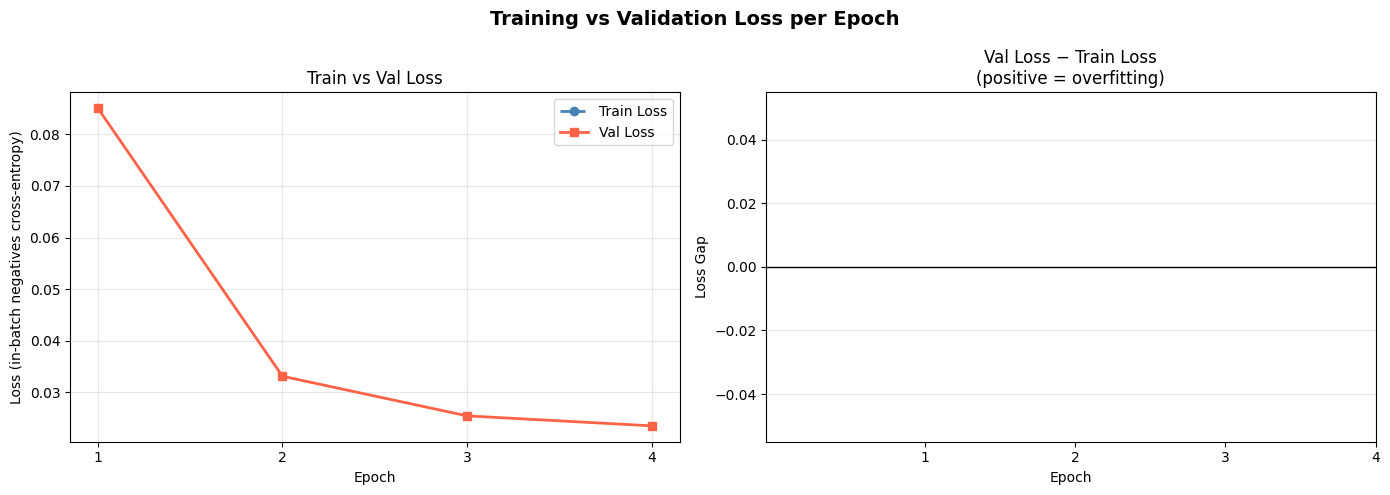

Saved: loss_per_epoch.png


In [26]:
# ─── CELL 24: Loss over epochs ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training vs Validation Loss per Epoch", fontsize=14, fontweight="bold")

axes[0].plot(eval_epochs, train_loss_per_epoch, marker="o", linestyle="--",
             color="steelblue", linewidth=2, label="Train Loss")
axes[0].plot(eval_epochs, eval_loss, marker="s", linestyle="-",
             color="tomato", linewidth=2, label="Val Loss")
axes[0].set_title("Train vs Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (in-batch negatives cross-entropy)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(eval_epochs)

gap = [e - t if not np.isnan(t) else float("nan")
       for e, t in zip(eval_loss, train_loss_per_epoch)]
axes[1].bar(eval_epochs, gap,
            color=["tomato" if g > 0 else "steelblue" for g in gap],
            alpha=0.8, edgecolor="black", linewidth=0.5)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Val Loss − Train Loss\n(positive = overfitting)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss Gap")
axes[1].set_xticks(eval_epochs)
axes[1].grid(True, alpha=0.3, axis="y")
for ep, g in zip(eval_epochs, gap):
    if not np.isnan(g):
        axes[1].text(ep, g + (0.001 if g >= 0 else -0.003),
                     f"{g:+.4f}", ha="center",
                     va="bottom" if g >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_per_epoch.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: loss_per_epoch.png")

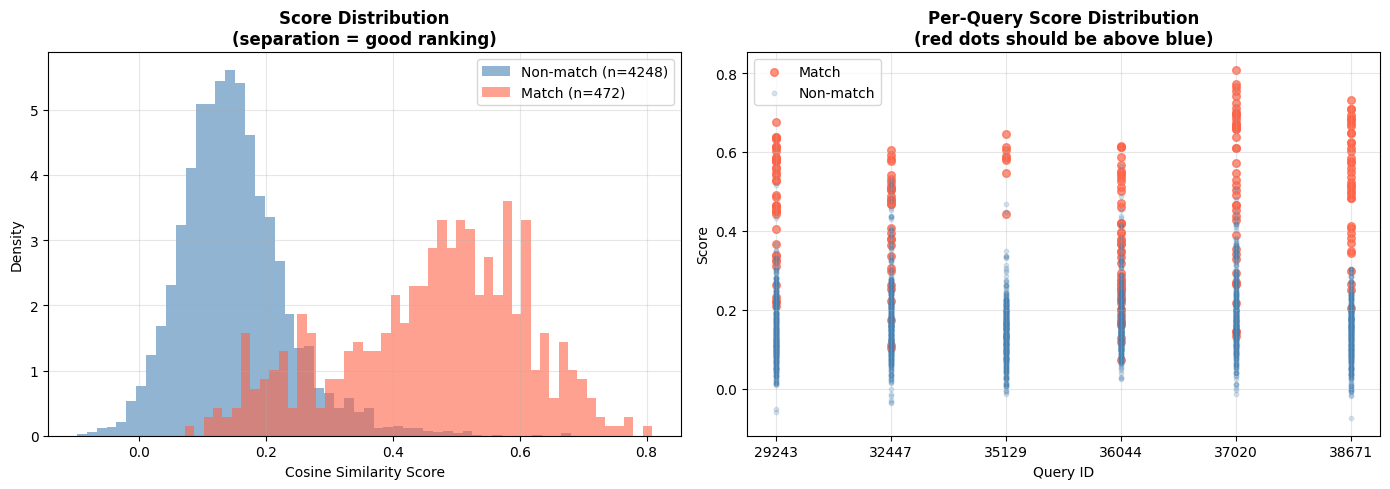

In [27]:
# ─── CELL 25: Precision-Recall curve ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_scores = probs[labels == 1]
neg_scores = probs[labels == 0]

axes[0].hist(neg_scores, bins=50, alpha=0.6, color="steelblue",
             density=True, label=f"Non-match (n={len(neg_scores)})")
axes[0].hist(pos_scores, bins=50, alpha=0.6, color="tomato",
             density=True, label=f"Match (n={len(pos_scores)})")
axes[0].set_title("Score Distribution\n(separation = good ranking)", fontweight="bold")
axes[0].set_xlabel("Cosine Similarity Score")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for qid, grp in list(df_dev.groupby("q_id"))[:6]:
    pos_s = grp[grp["relevance"]==1]["pred_prob"].values
    neg_s = grp[grp["relevance"]==0]["pred_prob"].values
    axes[1].scatter([str(qid)]*len(pos_s), pos_s,
                    color="tomato", alpha=0.7, s=30, label="Match" if qid == list(df_dev["q_id"].unique())[0] else "")
    axes[1].scatter([str(qid)]*len(neg_s), neg_s,
                    color="steelblue", alpha=0.2, s=10, label="Non-match" if qid == list(df_dev["q_id"].unique())[0] else "")

axes[1].set_title("Per-Query Score Distribution\n(red dots should be above blue)", fontweight="bold")
axes[1].set_xlabel("Query ID")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

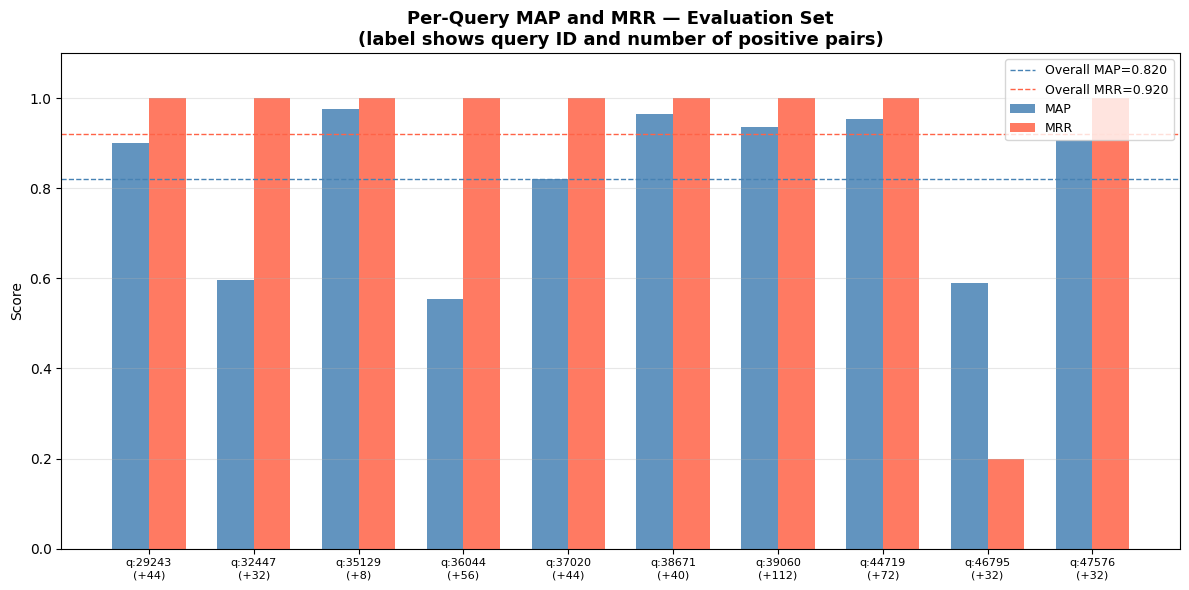

Saved: per_query_map_mrr.png


In [28]:
# ─── CELL 26: Per-query ranking metrics breakdown ──────────

query_ids, query_maps, query_mrrs, query_pos_counts = [], [], [], []

for qid, grp in df_dev.groupby("q_id"):
    grp_sorted = grp.sort_values("pred_prob", ascending=False).reset_index(drop=True)
    rel = grp_sorted["relevance"].values

    # MAP
    hits, ap = 0, 0.0
    for rank, r in enumerate(rel, start=1):
        if r == 1:
            hits += 1
            ap += hits / rank
    q_map = ap / rel.sum() if rel.sum() > 0 else 0.0

    # MRR
    q_mrr = 0.0
    for rank, r in enumerate(rel, start=1):
        if r == 1:
            q_mrr = 1.0 / rank
            break

    query_ids.append(str(qid))
    query_maps.append(q_map)
    query_mrrs.append(q_mrr)
    query_pos_counts.append(int(rel.sum()))

x = np.arange(len(query_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(max(12, len(query_ids) * 1.2), 6))
bars1 = ax.bar(x - width/2, query_maps, width, label="MAP",  color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, query_mrrs, width, label="MRR",  color="tomato",    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f"q:{qid}\n(+{n})" for qid, n in zip(query_ids, query_pos_counts)],
                   fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Per-Query MAP and MRR — Evaluation Set\n"
             "(label shows query ID and number of positive pairs)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(y=MAP, color="steelblue", linestyle="--", linewidth=1,
           label=f"Overall MAP={MAP:.3f}")
ax.axhline(y=MRR, color="tomato",    linestyle="--", linewidth=1,
           label=f"Overall MRR={MRR:.3f}")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/per_query_map_mrr.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: per_query_map_mrr.png")